In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('./data/mall_customers_clustering.csv', index_col=0)
df.head()

,CustomerID,Genre,Age,Income,Score
0,1,Male,19,15000,0.39
1,2,Male,21,15000,0.81
2,3,Female,20,16000,0.06
3,4,Female,23,16000,0.77
4,5,Female,31,17000,0.40


<Axes: xlabel='Income', ylabel='Score'>

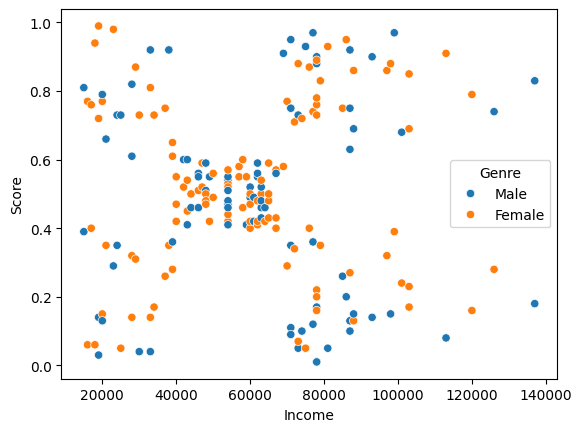

In [4]:
sns.scatterplot(x='Income' , y='Score',data=df , hue='Genre')

In [5]:
x = df.drop(["CustomerID"], axis=1)
X = pd.get_dummies(x)

In [6]:
from sklearn.cluster import KMeans

k_means = KMeans(n_clusters=3, random_state=42).fit(X)

In [7]:
y_kmeans = k_means.labels_

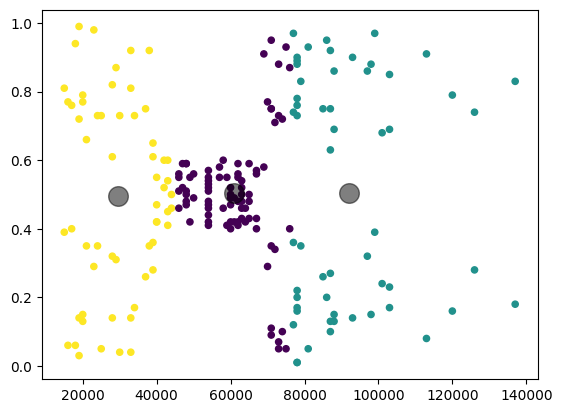

In [10]:
plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.show()

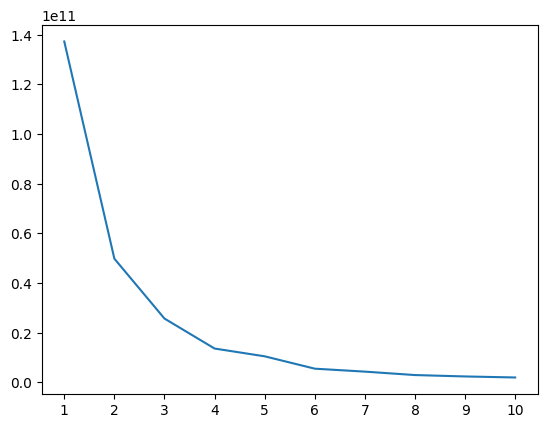

In [11]:
wcss = []
for i in range(1,11):
	k_means = KMeans(n_clusters=i,random_state=42)
	k_means.fit(X)
	wcss.append(k_means.inertia_)
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
_ = plt.show()

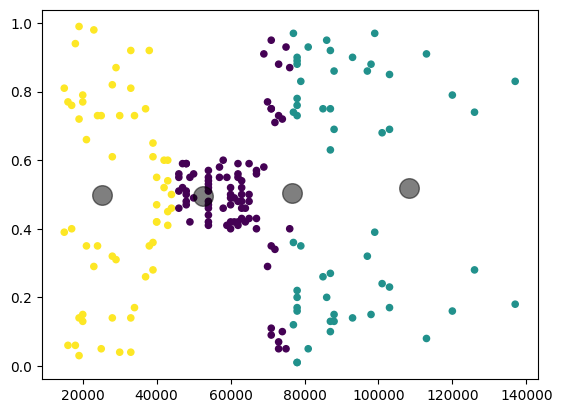

In [13]:
k_means = KMeans(n_clusters=4, random_state=42).fit(X)

plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.show()

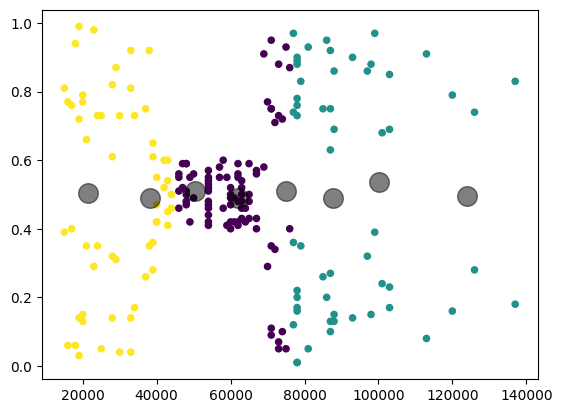

In [14]:
k_means = KMeans(n_clusters=8, random_state=42).fit(X)

plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Age,Income,Score,Genre_Female,Genre_Male
0,-1.424569,-1.738999,-0.434801,-1.128152,1.128152
1,-1.281035,-1.738999,1.195704,-1.128152,1.128152
2,-1.352802,-1.700830,-1.715913,0.886405,-0.886405
3,-1.137502,-1.700830,1.040418,0.886405,-0.886405
4,-0.563369,-1.662660,-0.395980,0.886405,-0.886405


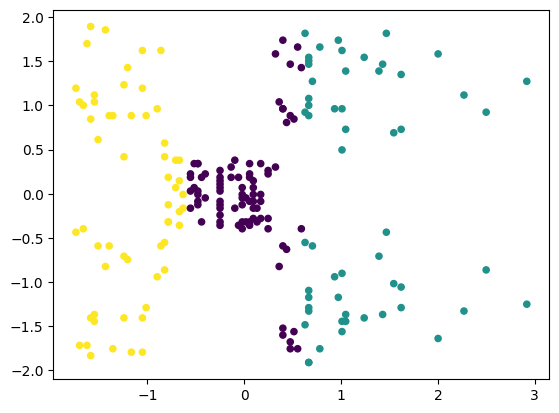

In [17]:
plt.scatter(X_scaled.Income, X_scaled.Score, c=y_kmeans, s=20, cmap='viridis')
plt.show()

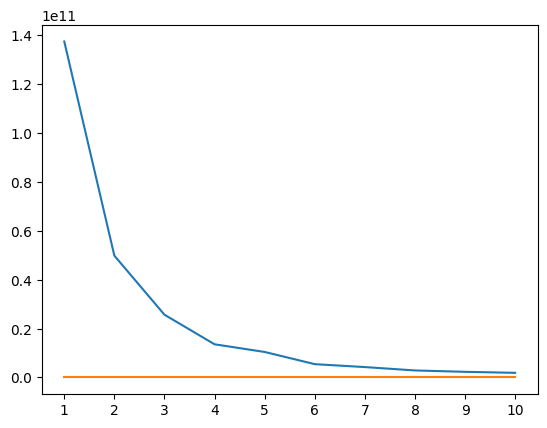

In [18]:
unscaled, scaled = [], []
for i in range(1,11):
	unscaled.append(KMeans(n_clusters=i,random_state=42).fit(X).inertia_)
	scaled.append(KMeans(n_clusters=i,random_state=42).fit(X_scaled).inertia_)
plt.plot(range(1,11),unscaled)
plt.plot(range(1,11),scaled)
plt.xticks(range(1,11))
_ = plt.show()

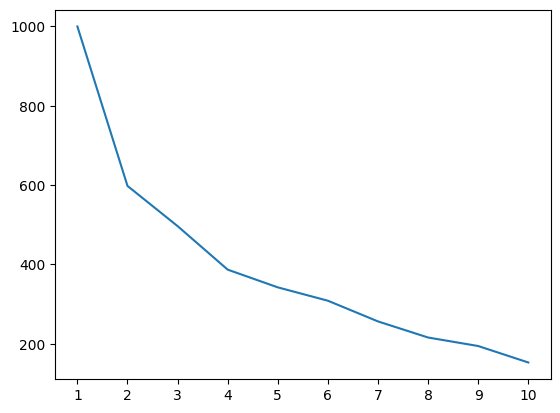

In [19]:
unscaled, scaled = [], []
for i in range(1,11):
	unscaled.append(KMeans(n_clusters=i,random_state=42).fit(X).inertia_)
	scaled.append(KMeans(n_clusters=i,random_state=42).fit(X_scaled).inertia_)
plt.plot(range(1,11),scaled)
plt.xticks(range(1,11))
_ = plt.show()

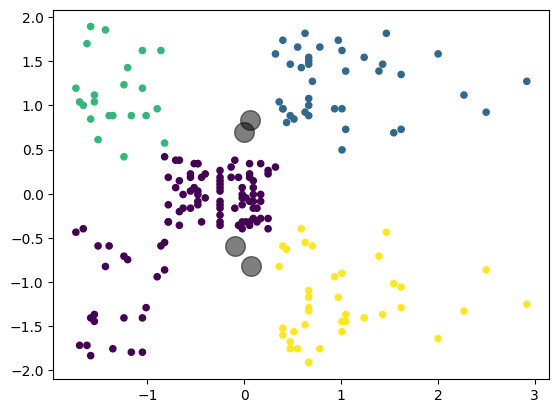

In [29]:
k_means = KMeans(n_clusters=4, random_state=42).fit(X_scaled)

plt.scatter(X_scaled.Income, X_scaled.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.show()

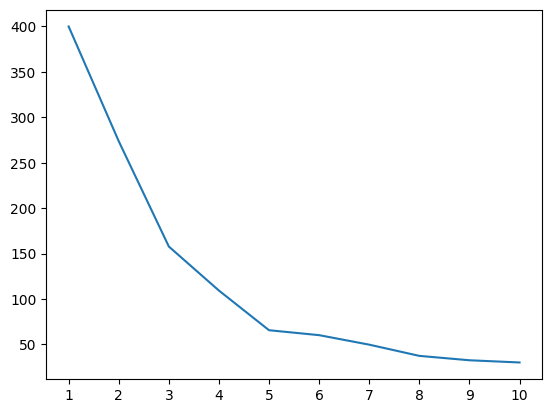

In [23]:
X_flat = X_scaled.drop(["Age", "Genre_Female", "Genre_Male"], axis=1)
X_flat.head()

scaled = []
for i in range(1,11):
	scaled.append(KMeans(n_clusters=i,random_state=42).fit(X_flat).inertia_)
plt.plot(range(1,11),scaled)
plt.xticks(range(1,11))
_ = plt.show()

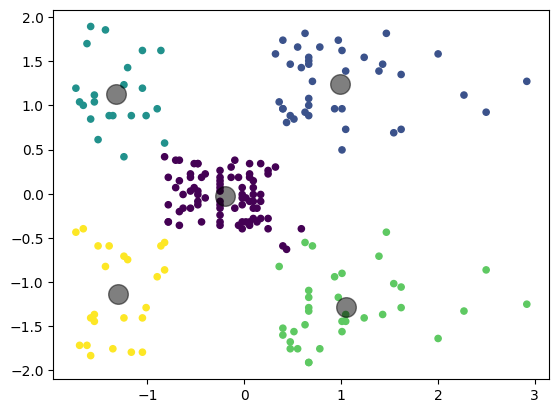

In [27]:
k_means = KMeans(n_clusters=5, random_state=42).fit(X_flat)
y_kmeans = k_means.labels_

plt.scatter(X_flat.Income, X_flat.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.show()

In [30]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(X_scaled)

In [31]:
from scipy.cluster.hierarchy import dendrogram

In [32]:
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

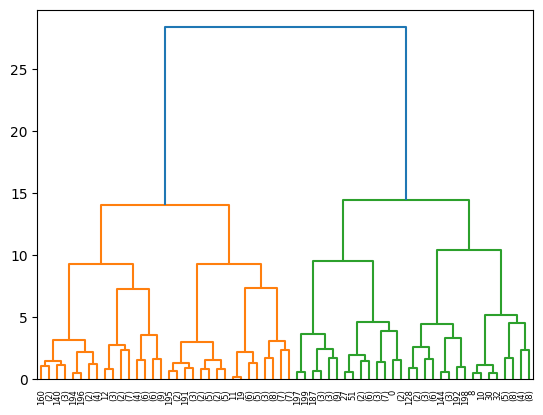

In [33]:
plot_dendrogram(model, truncate_mode="level", p=5)

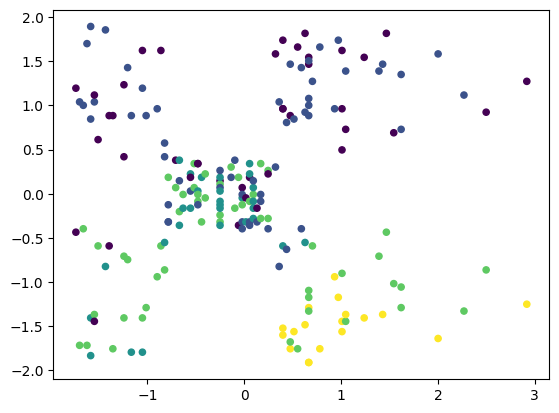

In [34]:
agg_clustering = AgglomerativeClustering(n_clusters=5).fit(X_scaled)
y_agg = agg_clustering.labels_

plt.scatter(X_flat.Income, X_flat.Score, c=y_agg, s=20, cmap='viridis')

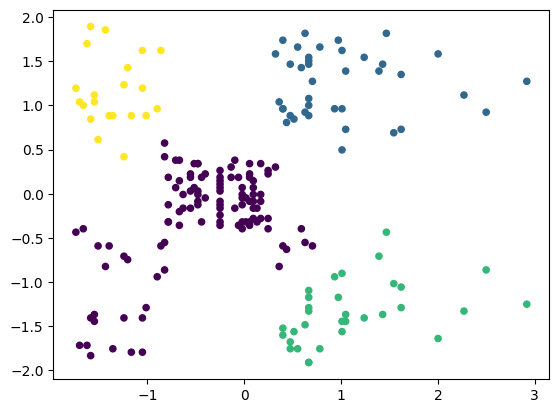

In [35]:
agg_clustering = AgglomerativeClustering(n_clusters=4).fit(X_flat)
y_agg = agg_clustering.labels_

plt.scatter(X_flat.Income, X_flat.Score, c=y_agg, s=20, cmap='viridis')

In [36]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.4, min_samples=3).fit(X_flat)
y_db = db.labels_

In [37]:
n_clusters_ = len(set(y_db)) - (1 if -1 in y_db else 0)
n_noise_ = list(y_db).count(-1)

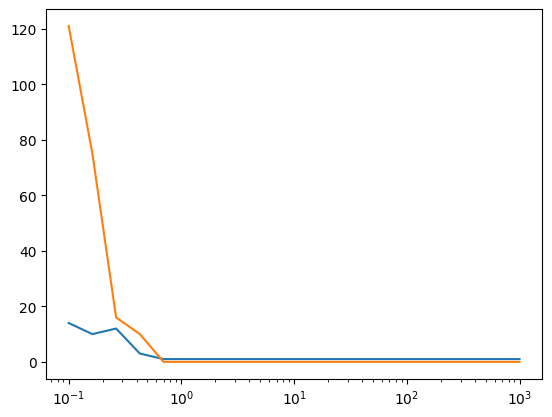

In [38]:
clusters, noise = [], []
for i in np.logspace(-1, 3, 20):
  db = DBSCAN(eps=i, min_samples=3).fit(X_flat)
  y_db = db.labels_

  clusters.append(len(set(y_db)) - (1 if -1 in y_db else 0))
  noise.append(list(y_db).count(-1))

plt.plot(np.logspace(-1, 3, 20),clusters)
plt.plot(np.logspace(-1, 3, 20),noise)
plt.xscale('log')
_ = plt.show()

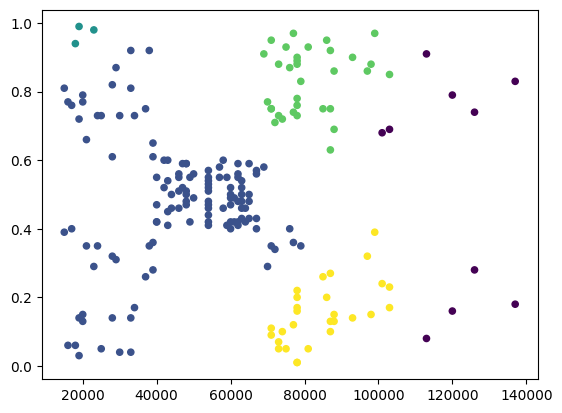

In [39]:
db = DBSCAN(eps=0.4, min_samples=3).fit(X_flat)
y_db = db.labels_

plt.scatter(X.Income, X.Score, c=y_db, s=20, cmap='viridis')

# EXTRA TASKS
# 1

In [40]:
k_means = KMeans(n_clusters=5, random_state=42).fit(X_flat)
y_kmeans = k_means.labels_

analysis_df = df.copy()
analysis_df["cluster"] = y_kmeans

print("cluster sizes:")
print(analysis_df["cluster"].value_counts().sort_index())

print("cluster averages:")
print(analysis_df.groupby("cluster")[["Age", "Income", "Score"]].mean().round(2))

centers = k_means.cluster_centers_
X_arr = X_flat.values
rep_rows = []

for c in range(k_means.n_clusters):
    idx = np.where(y_kmeans == c)[0]
    d = np.linalg.norm(X_arr[idx] - centers[c], axis=1)
    nearest_idx = idx[np.argsort(d)[:5]]
    rep_rows.append(
        analysis_df.iloc[nearest_idx][["CustomerID", "Genre", "Age", "Income", "Score", "cluster"]]
    )

representative_points = pd.concat(rep_rows).sort_values(["cluster", "Income", "Score"])
display(representative_points)

cluster sizes:
cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64
cluster averages:
           Age    Income  Score
cluster                        
0        42.72  55296.30   0.50
1        32.69  86538.46   0.82
2        25.27  25727.27   0.79
3        41.11  88200.00   0.17
4        45.22  26304.35   0.21


,CustomerID,Genre,Age,Income,Score,cluster
74,75,Male,59,54000,0.47,0
77,78,Male,40,54000,0.48,0
80,81,Male,57,54000,0.51,0
78,79,Female,23,54000,0.52,0
76,77,Female,45,54000,0.53,0
157,158,Female,30,78000,0.78,1
161,162,Female,29,79000,0.83,1
165,166,Female,36,85000,0.75,1
171,172,Male,28,87000,0.75,1
175,176,Female,30,88000,0.86,1


# 2

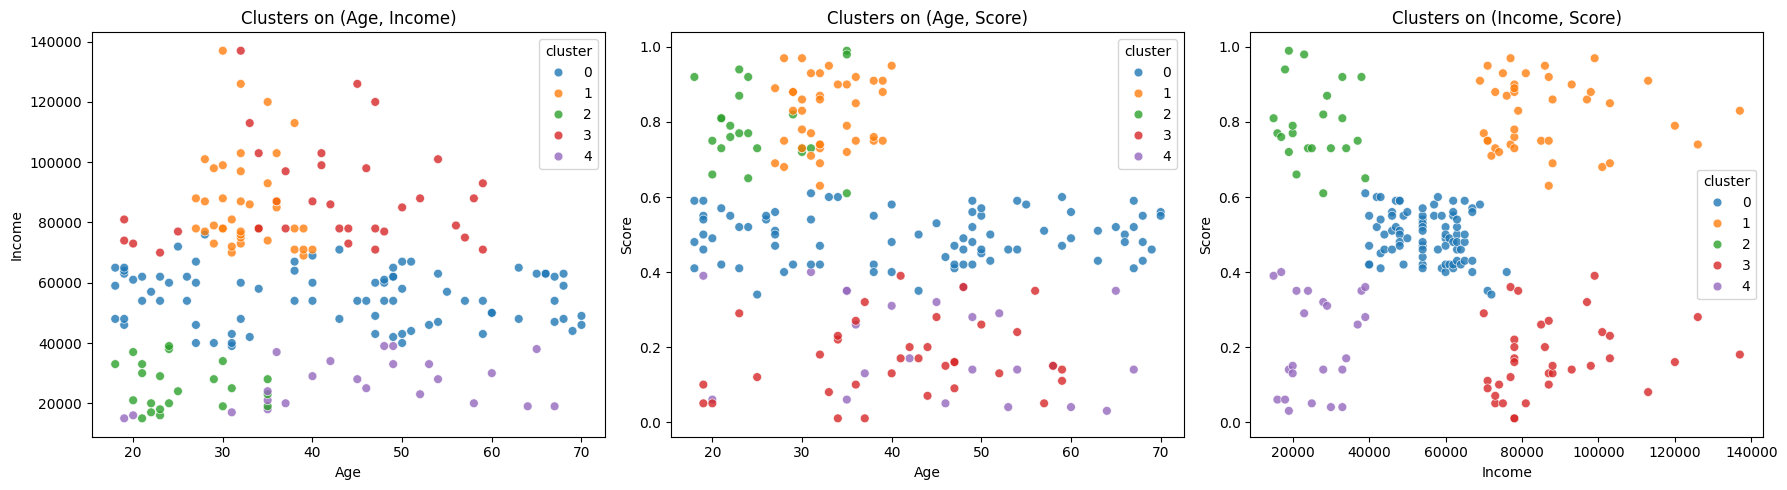

In [ ]:
import itertools

plot_df = df.copy()
plot_df["cluster"] = y_kmeans

feature_pairs = list(itertools.combinations(["Age", "Income", "Score"], 2))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (f1, f2) in zip(axes, feature_pairs):
    sns.scatterplot(
        data=plot_df,
        x=f1,
        y=f2,
        hue="cluster",
        palette="tab10",
        alpha=0.8,
        s=40,
        ax=ax
    )
    ax.set_title(f"Clusters on ({f1}, {f2})")

plt.tight_layout()
plt.show()

# income-score clusters are the most distinct


# 3

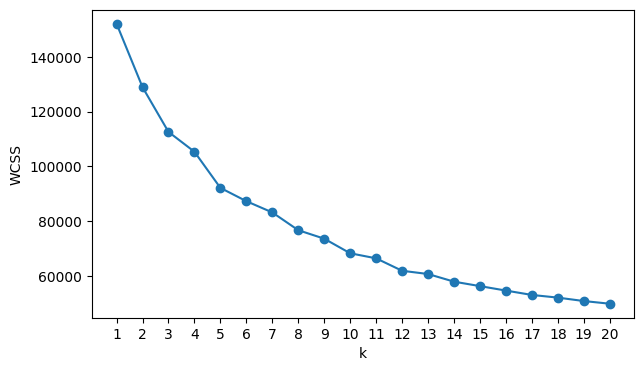

cluster sizes:
cluster
0     977
1    1487
2    3118
3    3368
Name: count, dtype: int64


In [47]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score

cc = pd.read_csv("./data/credit_card_clustering.csv")
cc = cc.drop(columns=["CUST_ID"], errors="ignore")

imputer = SimpleImputer(strategy="median")
cc_imputed = pd.DataFrame(imputer.fit_transform(cc), columns=cc.columns)

scaler_cc = StandardScaler()
cc_scaled = pd.DataFrame(scaler_cc.fit_transform(cc_imputed), columns=cc_imputed.columns)

wcss_cc = []
for k in range(1, 21):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(cc_scaled)
    wcss_cc.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 21), wcss_cc, marker="o")
plt.xticks(range(1, 21))
plt.xlabel("k")
plt.ylabel("WCSS")
plt.show()

km_cc = KMeans(n_clusters=4, random_state=42).fit(cc_scaled)
y_km_cc = km_cc.labels_

cc_profile = cc_imputed.copy()
cc_profile["cluster"] = y_km_cc

print("cluster sizes:")
print(cc_profile["cluster"].value_counts().sort_index())

# 4

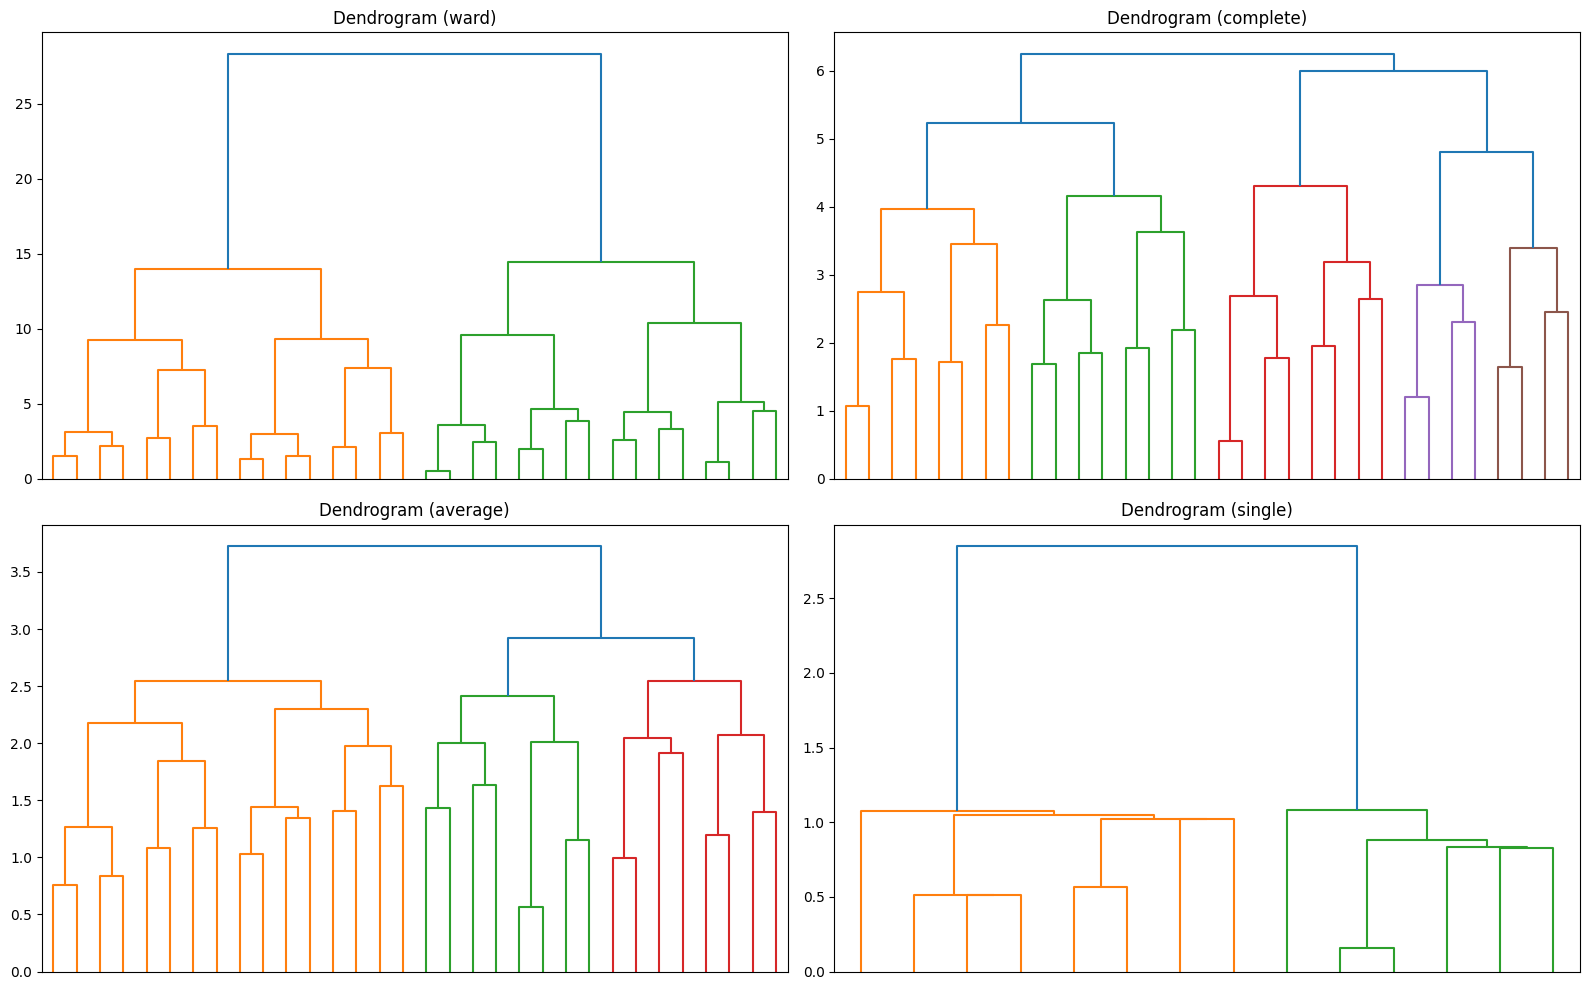

score by linkage:
ward: 0.3334
complete: 0.2530
average: 0.3341
single: 0.1645


In [49]:
import scipy.cluster.hierarchy as sch

H = X_scaled.copy()
methods = ["ward", "complete", "average", "single"]

plt.figure(figsize=(16, 10))
for i, m in enumerate(methods, 1):
    plt.subplot(2, 2, i)
    Z = sch.linkage(H, method=m)
    sch.dendrogram(Z, truncate_mode="level", p=4, no_labels=True)
    plt.title(f"Dendrogram ({m})")
plt.tight_layout()
plt.show()

sil_scores = {}
for m in methods:
    model_h = AgglomerativeClustering(n_clusters=5, linkage=m)
    labels_h = model_h.fit_predict(H)
    sil_scores[m] = silhouette_score(H, labels_h)

print("score by linkage:")
for m, s in sil_scores.items():
    print(f"{m}: {s:.4f}")

# 5

In [51]:
D = X_flat.values

def dbscan_wcss(X_arr, labels):
    mask = labels != -1
    Xc = X_arr[mask]
    lc = labels[mask]
    unique = np.unique(lc)

    if len(unique) == 0:
        return np.nan, 0, int(np.sum(~mask))

    wcss_value = 0.0
    for c in unique:
        pts = Xc[lc == c]
        center = pts.mean(axis=0)
        wcss_value += np.sum((pts - center) ** 2)

    return wcss_value, len(unique), int(np.sum(~mask))

# DBSCAN result
db = DBSCAN(eps=0.4, min_samples=3).fit(D)
y_db = db.labels_
db_wcss, db_k, db_noise = dbscan_wcss(D, y_db)

print(f"DBSCAN: clusters={db_k}, noise={db_noise}, WCSS={db_wcss:.4f}")

if db_k >= 1:
    km_comp = KMeans(n_clusters=db_k, random_state=42).fit(D)
    km_wcss = km_comp.inertia_
    print(f"KMeans (k={db_k}): WCSS={km_wcss:.4f}")

    if db_k >= 2:
        mask = y_db != -1
        sil_db = silhouette_score(D[mask], y_db[mask])
        sil_km = silhouette_score(D, km_comp.labels_)
        print(f"sil DBSCAN (no noise): {sil_db:.4f}")
        print(f"sil KMeans: {sil_km:.4f}")


DBSCAN: clusters=4, noise=10, WCSS=128.7366
KMeans (k=4): WCSS=109.2282
sil DBSCAN (no noise): 0.3954
sil KMeans: 0.4943


# 6

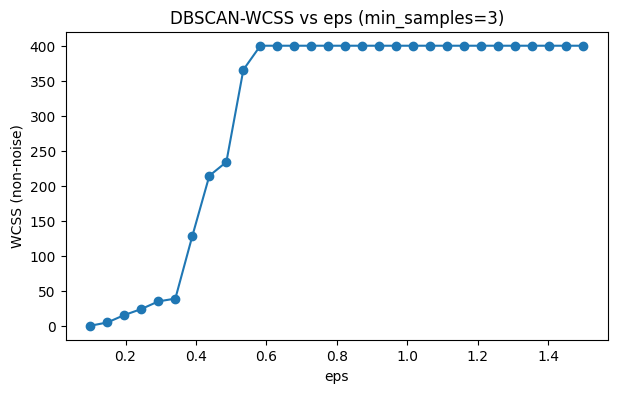

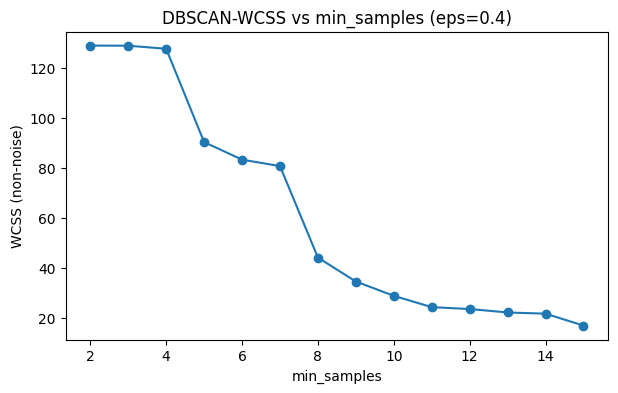

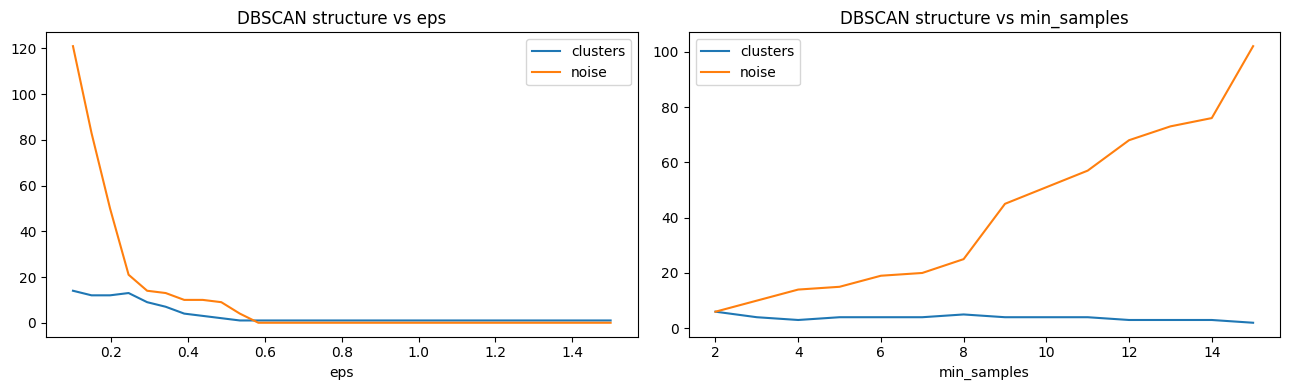

In [52]:
def dbscan_wcss_only(X_arr, labels):
    mask = labels != -1
    Xc = X_arr[mask]
    lc = labels[mask]
    unique = np.unique(lc)

    if len(unique) == 0:
        return np.nan

    wcss_value = 0.0
    for c in unique:
        pts = Xc[lc == c]
        center = pts.mean(axis=0)
        wcss_value += np.sum((pts - center) ** 2)
    return wcss_value

eps_values = np.linspace(0.1, 1.5, 30)
min_samples_values = list(range(2, 16))

fixed_ms = 3
wcss_eps, clusters_eps, noise_eps = [], [], []
for eps in eps_values:
    labels = DBSCAN(eps=eps, min_samples=fixed_ms).fit_predict(D)
    wcss_eps.append(dbscan_wcss_only(D, labels))
    clusters_eps.append(len(set(labels)) - (1 if -1 in labels else 0))
    noise_eps.append(int(np.sum(labels == -1)))

plt.figure(figsize=(7, 4))
plt.plot(eps_values, wcss_eps, marker="o")
plt.title("DBSCAN-WCSS vs eps (min_samples=3)")
plt.xlabel("eps")
plt.ylabel("WCSS (non-noise)")
plt.show()

fixed_eps = 0.4
wcss_ms, clusters_ms, noise_ms = [], [], []
for ms in min_samples_values:
    labels = DBSCAN(eps=fixed_eps, min_samples=ms).fit_predict(D)
    wcss_ms.append(dbscan_wcss_only(D, labels))
    clusters_ms.append(len(set(labels)) - (1 if -1 in labels else 0))
    noise_ms.append(int(np.sum(labels == -1)))

plt.figure(figsize=(7, 4))
plt.plot(min_samples_values, wcss_ms, marker="o")
plt.title("DBSCAN-WCSS vs min_samples (eps=0.4)")
plt.xlabel("min_samples")
plt.ylabel("WCSS (non-noise)")
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(eps_values, clusters_eps, label="clusters")
ax[0].plot(eps_values, noise_eps, label="noise")
ax[0].set_title("DBSCAN structure vs eps")
ax[0].set_xlabel("eps")
ax[0].legend()

ax[1].plot(min_samples_values, clusters_ms, label="clusters")
ax[1].plot(min_samples_values, noise_ms, label="noise")
ax[1].set_title("DBSCAN structure vs min_samples")
ax[1].set_xlabel("min_samples")
ax[1].legend()

plt.tight_layout()
plt.show()